In [768]:
import warnings
warnings.filterwarnings("ignore")

## Imports

In [769]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [770]:
from funcoes_escoragem import *

In [771]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Base

In [772]:
model_vars = [
    "score_proposto__bvs",
    "SERASA_CHSV5",
    "age",
    "property_type",
    "qtde_restricoes__consulta_realizada",
    "income_commitment",
    "agency_pc4_mais_100_contratos__pc_categorias",
    "city_pc4_mais_100_contratos__pc_categorias",
    "flag_tem__contratos_anteriores",
    "flag_teve_boleto_atrasado__contratos_anteriores",
    "agency_pc4_mais_100_contratos__pc_categorias_is_null",
    "city_pc4_mais_100_contratos__pc_categorias_is_null",
    "rental_value",
    "income",
    "pred_blend4_1_to_score",
]

In [773]:
df_blend4_dev = pd.read_csv(ANALYTICS_DIR/"df_predict_blend4.csv")#.drop(columns=["city_pc4_mais_100_contratos__pc_categorias"])
df_blend4_dev["safra"] = df_blend4_dev["requested_at"].astype(str).str[:7]
df_blend4_dev["contract_id"] = pd.to_numeric(df_blend4_dev["contract_id"], errors="coerce").astype("Int64")
# df_blend4_dev = df_blend4_dev[df_blend4_dev["agency_pc4_mais_100_contratos__pc_categorias"]!=0]
# df_blend4_dev = df_blend4_dev[df_blend4_dev["safra"]!="2026-06"]
df_blend4_dev = df_blend4_dev[df_blend4_dev["income"]>0]
df_blend4_dev["request_imovel_codigo_cidade_ibge"] = (pd.to_numeric(df_blend4_dev["request_imovel_codigo_cidade_ibge"], errors="coerce").astype("Int64"))
df_blend4_dev["request_imobiliariaId"] = (pd.to_numeric(df_blend4_dev["request_imobiliariaId"], errors="coerce").astype("Int64"))
df_blend4_dev = df_blend4_dev[df_blend4_dev["message_decisao"].isin(["BLEND3_3", "BLEND3_4", "BLEND_4"])]
# df_blend4_dev = df_blend4_dev[df_blend4_dev["requested_at"]>= "2026-07-05"]
df_blend4_dev

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,qtd_proponentes,score_imobiliaria,model,id_consulta,id_funcionalidade,documento,...,qtde_restricoes__consulta_realizada__normalized4_1,income_commitment__normalized4_1,agency_pc4_mais_100_contratos__pc_categorias__normalized4_1,city_pc4_mais_100_contratos__pc_categorias__normalized4_1,pred_blend4_1,pred_blend4_1_to_score,rating_manual_blend4,rating_json_blend4,rating_cl_pol_blend4,safra
0,14392885771,4131211,2026-06-04,2026-06-04,1,NI,BLEND3_3,5899338,32,14392885771,...,0.0,2.150937,0.000000,-0.844994,0.518840,481.0,A,D,7.B,2026-06
1,47697497832,4174216,2026-05-26,2026-05-26,1,E,BLEND3_3,5850339,33,47697497832,...,8.0,0.125185,0.000000,0.551021,0.592440,408.0,C,E,9.D+,2026-05
2,7013437379,4175026,2026-05-26,2026-05-26,1,Z,BLEND3_3,5851327,33,7013437379,...,1.0,1.153340,0.101459,0.882277,0.610756,389.0,D,E,10.D,2026-05
3,9620425448,4175994,2026-05-26,2026-05-26,1,B,BLEND3_3,5852494,33,9620425448,...,2.0,0.528269,0.000000,0.000000,0.517874,482.0,A,D,7.B,2026-05
4,13362189679,4179391,2026-05-27,2026-05-27,1,NI,BLEND3_3,5856793,33,13362189679,...,5.0,0.809205,0.000000,0.000000,0.546987,453.0,B,E,8.C,2026-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348435,58809704851,4515666,2026-08-14,2026-08-14,1,Z,BLEND3_4,6272827,33,58809704851,...,6.0,0.452325,0.000000,0.766126,0.592774,407.0,D,E,10.D,2026-08
348436,37080924812,4515857,2026-08-14,2026-08-14,1,NI,BLEND_4,6273074,31,37080924812,...,0.0,-0.109947,0.000000,-0.617386,0.207912,792.0,A,A,1.A+,2026-08
348437,29114265842,4516818,2026-08-15,2026-08-15,1,NI,BLEND3_4,6274240,31,29114265842,...,1.0,-0.801848,0.000000,0.294421,0.509791,490.0,A,A,7.B,2026-08
348438,47831376844,4517743,2026-08-16,2026-08-16,1,NI,BLEND3_4,6275424,33,47831376844,...,0.0,2.421539,0.000000,-0.534513,0.548726,451.0,B,E,8.C,2026-08


In [774]:
# df_teste[df_teste["contract_id"] == 4332078][["income", "message_decisao", "requested_at"]]

In [775]:
# df_blend4_dev[df_blend4_dev["contract_id"] == 4332078][["income", "message_decisao", "requested_at"]]

In [776]:
df_blend4_dev[df_blend4_dev["model"]=="BLEND_4"][["contract_id", "requested_at", "request_imovel_codigo_cidade_ibge"]]

,contract_id,requested_at,request_imovel_codigo_cidade_ibge
157,4333726,2026-07-05,<NA>
163,4339093,2026-07-06,<NA>
186,4361949,2026-07-13,<NA>
195,4371075,2026-07-14,<NA>
200,4374704,2026-07-15,<NA>
...,...,...,...
348428,4510276,2026-08-13,<NA>
348429,4510364,2026-08-13,<NA>
348431,4513034,2026-08-14,<NA>
348432,4513875,2026-08-14,<NA>


In [777]:
df_blend4_dev[df_blend4_dev["message_decisao"]=="BLEND_4"]["request_imovel_codigo_cidade_ibge"]

157       <NA>
163       <NA>
186       <NA>
195       <NA>
200       <NA>
          ... 
348428    <NA>
348429    <NA>
348431    <NA>
348432    <NA>
348436    <NA>
Name: request_imovel_codigo_cidade_ibge, Length: 45759, dtype: Int64

In [778]:
df_blend4_dev[df_blend4_dev["message_decisao"]=="BLEND3_4"][["contract_id", "requested_at", "request_imovel_codigo_cidade_ibge"]]

,contract_id,requested_at,request_imovel_codigo_cidade_ibge
269,4454475,2026-08-03,4202404
271,4457010,2026-08-03,3550308
278,4463383,2026-08-04,3538709
279,4463620,2026-08-04,3303302
281,4464435,2026-08-04,3500303
...,...,...,...
348434,4514773,2026-08-14,3304557
348435,4515666,2026-08-14,3526902
348437,4516818,2026-08-15,4113700
348438,4517743,2026-08-16,3524402


In [779]:
df_blend4_dev["request_imobiliariaId"]

0         29311
1          1156
2          1018
3         33297
4         56549
          ...  
348435    24884
348436    56763
348437    49038
348438     4000
348439     3552
Name: request_imobiliariaId, Length: 264742, dtype: Int64

## Utilizar PC Cidades 2025-12/2026-01

In [780]:
project_id = 'loft-dl-datascience'

query_city = '''
select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_cidade
'''

df_city = pd.read_gbq(query_city, project_id=project_id)
df_city

,mes_referencia,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias
0,2025-12-01,3522307,0.028125
1,2025-12-01,5003702,0.030303
2,2025-12-01,4216206,0.033113
3,2025-12-01,5008305,0.036496
4,2025-12-01,3500105,0.039216
...,...,...,...
1709,2026-08-01,3533908,0.180328
1710,2026-08-01,3122306,0.183087
1711,2026-08-01,2800308,0.204589
1712,2026-08-01,4313300,0.207407


In [781]:
df_city_202605 = df_city[df_city["mes_referencia"]==pd.to_datetime("2026-05-01")]
df_city_202605["id_cidade_ibge"] = (pd.to_numeric(df_city_202605["id_cidade_ibge"], errors="coerce").astype("Int64"))
df_city_202605

,mes_referencia,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias
941,2026-05-01,5008305,0.014493
942,2026-05-01,3521408,0.016949
943,2026-05-01,2507507,0.030534
944,2026-05-01,3504008,0.030864
945,2026-05-01,3522307,0.032258
...,...,...,...
1128,2026-05-01,2933307,0.190000
1129,2026-05-01,3533908,0.200637
1130,2026-05-01,2800308,0.201207
1131,2026-05-01,5218805,0.201299


## Utilizar PC Agency/Imob

In [782]:
project_id = 'loft-dl-datascience'

query_agency = '''
select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_imobiliaria
'''

df_agency = pd.read_gbq(query_agency, project_id=project_id)
df_agency

,mes_referencia,agency_id,agency_pc4_mais_100_contratos__pc_categorias
0,2025-12-01,9706,0.019417
1,2025-12-01,1399,0.021429
2,2025-12-01,4420,0.024390
3,2025-12-01,4926,0.026738
4,2025-12-01,9418,0.028571
...,...,...,...
1284,2026-08-01,10433,0.282258
1285,2026-08-01,592,0.294521
1286,2026-08-01,25913,0.300699
1287,2026-08-01,3419,0.318182


In [783]:
df_agency_202605 = df_agency[df_agency["mes_referencia"]==pd.to_datetime("2026-05-01")]
df_agency_202605["agency_id"] = (pd.to_numeric(df_agency_202605["agency_id"], errors="coerce").astype("Int64"))
df_agency_202605

,mes_referencia,agency_id,agency_pc4_mais_100_contratos__pc_categorias
711,2026-05-01,9706,0.000000
712,2026-05-01,4926,0.014184
713,2026-05-01,5802,0.022388
714,2026-05-01,589,0.026393
715,2026-05-01,9075,0.027523
...,...,...,...
856,2026-05-01,4249,0.288889
857,2026-05-01,3419,0.302239
858,2026-05-01,9118,0.305970
859,2026-05-01,2874,0.330827


## Variáveis Faltantes

In [784]:
query = '''
WITH property_type AS (
  SELECT
    id AS contract_id,
    CASE WHEN tp_imovel = 2 THEN 0 ELSE 1 END AS property_type,
    CAST(id_cidade_ibge AS INT64) AS id_cidade_ibge,    --nova
    CAST(id_imobiliaria AS INT64) AS agency_id,  --nova
    DATE(criado_em) AS requested_at
  FROM `loft-dl-fintech.bronze_credpago_enriched.imovel`
  WHERE DATE(criado_em) >= DATE('2026-01-01')
  QUALIFY ROW_NUMBER() OVER (PARTITION BY id ORDER BY criado_em DESC) = 1
),

rental_value AS (
  SELECT
    id_imovel AS contract_id,
    CAST(vl_aluguel AS FLOAT64) AS rental_value,
    DATE(data) AS requested_at
  FROM `loft-dl-fintech.bronze_credpago_snapshot.historico_valor`
  WHERE DATE(data) >= DATE('2026-01-01')
  QUALIFY ROW_NUMBER() OVER (PARTITION BY id_imovel ORDER BY data DESC) = 1
)

SELECT
  COALESCE(p.contract_id, r.contract_id) AS contract_id,
  GREATEST(p.requested_at, r.requested_at) AS requested_at,
  p.property_type,
  p.id_cidade_ibge,
  p.agency_id,
  r.rental_value
FROM property_type p
FULL OUTER JOIN rental_value r
  ON p.contract_id = r.contract_id
'''

In [785]:
vars_faltantes = pd.read_gbq(query, project_id=project_id)
vars_faltantes["contract_id"] = pd.to_numeric(vars_faltantes["contract_id"], errors="coerce").astype("Int64")
vars_faltantes["id_cidade_ibge"] = pd.to_numeric(vars_faltantes["id_cidade_ibge"], errors="coerce").astype("Int64")
vars_faltantes["agency_id"] = pd.to_numeric(vars_faltantes["agency_id"], errors="coerce").astype("Int64")
vars_faltantes

,contract_id,requested_at,property_type,id_cidade_ibge,agency_id,rental_value
0,3568871,2026-01-01,1,3170206,47404,1500.00
1,3568875,2026-01-01,1,4202107,30930,2500.00
2,3569101,2026-01-02,1,4313409,574,1350.00
3,3569132,2026-01-02,1,4301602,406,1650.00
4,3569271,2026-01-02,1,3525300,1669,2200.00
...,...,...,...,...,...,...
1136026,3056092,NaT,<NA>,<NA>,<NA>,884.00
1136027,3078037,NaT,<NA>,<NA>,<NA>,1988.16
1136028,3104456,NaT,<NA>,<NA>,<NA>,901.00
1136029,3531716,NaT,<NA>,<NA>,<NA>,2000.00


In [786]:
vars_faltantes.to_parquet(ANALYTICS_DIR/"df_vars_faltantes_pc.parquet")

## Cruzar Bases

In [787]:
# .drop(columns=["agency_pc4_mais_100_contratos__pc_categorias"])
# .drop(columns=["city_pc4_mais_100_contratos__pc_categorias"])

In [853]:
df_predict = (df_blend4_dev.drop(columns=["agency_pc4_mais_100_contratos__pc_categorias", "city_pc4_mais_100_contratos__pc_categorias"])
    .merge(vars_faltantes[["contract_id", "id_cidade_ibge", "agency_id"]], left_on="contract_id", right_on="contract_id", how="left")
    .merge(df_city_202605[["id_cidade_ibge", "city_pc4_mais_100_contratos__pc_categorias"]], left_on="id_cidade_ibge", right_on="id_cidade_ibge", how="left")
    .merge(df_agency_202605[["agency_id", "agency_pc4_mais_100_contratos__pc_categorias"]], left_on="agency_id", right_on="agency_id", how="left")
)
df_predict

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,qtd_proponentes,score_imobiliaria,model,id_consulta,id_funcionalidade,documento,...,pred_blend4_1,pred_blend4_1_to_score,rating_manual_blend4,rating_json_blend4,rating_cl_pol_blend4,safra,id_cidade_ibge,agency_id,city_pc4_mais_100_contratos__pc_categorias,agency_pc4_mais_100_contratos__pc_categorias
0,14392885771,4131211,2026-06-04,2026-06-04,1,NI,BLEND3_3,5899338,32,14392885771,...,0.518840,481.0,A,D,7.B,2026-06,4202008,29311,0.071310,NaN
1,47697497832,4174216,2026-05-26,2026-05-26,1,E,BLEND3_3,5850339,33,47697497832,...,0.592440,408.0,C,E,9.D+,2026-05,3543402,1156,0.122789,NaN
2,7013437379,4175026,2026-05-26,2026-05-26,1,Z,BLEND3_3,5851327,33,7013437379,...,0.610756,389.0,D,E,10.D,2026-05,2304400,1018,0.135088,0.230769
3,9620425448,4175994,2026-05-26,2026-05-26,1,B,BLEND3_3,5852494,33,9620425448,...,0.517874,482.0,A,D,7.B,2026-05,3529302,33297,NaN,NaN
4,13362189679,4179391,2026-05-27,2026-05-27,1,NI,BLEND3_3,5856793,33,13362189679,...,0.546987,453.0,B,E,8.C,2026-05,3104007,56549,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264737,58809704851,4515666,2026-08-14,2026-08-14,1,Z,BLEND3_4,6272827,33,58809704851,...,0.592774,407.0,D,E,10.D,2026-08,3526902,24884,0.120974,NaN
264738,37080924812,4515857,2026-08-14,2026-08-14,1,NI,BLEND_4,6273074,31,37080924812,...,0.207912,792.0,A,A,1.A+,2026-08,3549904,56763,0.074803,NaN
264739,29114265842,4516818,2026-08-15,2026-08-15,1,NI,BLEND3_4,6274240,31,29114265842,...,0.509791,490.0,A,A,7.B,2026-08,4113700,49038,0.102014,NaN
264740,47831376844,4517743,2026-08-16,2026-08-16,1,NI,BLEND3_4,6275424,33,47831376844,...,0.548726,451.0,B,E,8.C,2026-08,3524402,4000,0.094320,NaN


In [854]:
df_predict[df_predict["message_decisao"]=="BLEND_4"].groupby(["id_cidade_ibge"], dropna=False).size()

id_cidade_ibge
1100023      2
1100049     15
1100122      8
1100205     29
1100304     11
          ... 
5220454      7
5221403     10
5221858      6
5300108    444
<NA>         1
Length: 786, dtype: int64

In [855]:
df_predict[df_predict["id_cidade_ibge"].isna()].groupby(["requested_at"], dropna=False).size()

requested_at
2026-06-09    1
2026-06-10    1
2026-06-25    1
2026-06-26    1
2026-07-01    1
2026-07-03    1
2026-07-21    1
2026-07-24    1
2026-08-05    1
2026-08-07    1
dtype: int64

In [856]:
df_predict[df_predict["request_imobiliariaId"].isna()].groupby(["requested_at"], dropna=False).size()

Series([], dtype: int64)

In [857]:
df_predict[df_predict["message_decisao"]=="BLEND_4"][["id_cidade_ibge", "city_pc4_mais_100_contratos__pc_categorias"]]

,id_cidade_ibge,city_pc4_mais_100_contratos__pc_categorias
118,4316907,0.118619
122,4205407,0.072010
140,4316808,0.059880
146,3550308,0.086642
150,3507506,0.111111
...,...,...
264731,4105508,0.075145
264732,3550308,0.086642
264733,4313375,NaN
264734,4113700,0.102014


## Variáveis

In [858]:
df_predict_vars = prepare_blend4_variables(df_predict)
df_predict_escorada = predict_blend4_1(df_predict_vars)

## Rating

In [859]:
score = pd.to_numeric(df_predict_escorada["pred_blend4_1_to_score"], errors="coerce")
bvs = pd.to_numeric(df_predict_escorada["SCORE_BVS"], errors="coerce")

conditions = [
    score.between(480, 1000),
    score.between(443, 479),
    score.between(408, 442),
    score.between(343, 407),
    score.between(0, 342),
    bvs <= 334,
]

choices = ["A", "B", "C", "D", "E", "E"]

df_predict_escorada["rating_simulado_blend4"] = np.select(conditions, choices, default=None)

In [860]:
df_predict_escorada[["contract_id", "requested_at", "rating_simulado_blend4", "rating_manual_blend4"]]

,contract_id,requested_at,rating_simulado_blend4,rating_manual_blend4
0,4131211,2026-06-04,A,A
1,4174216,2026-05-26,C,C
2,4175026,2026-05-26,D,D
3,4175994,2026-05-26,A,A
4,4179391,2026-05-27,B,B
...,...,...,...,...
264737,4515666,2026-08-14,C,D
264738,4515857,2026-08-14,A,A
264739,4516818,2026-08-15,A,A
264740,4517743,2026-08-16,C,B


In [861]:
df_predict_escorada.groupby("message_decisao", dropna=False).size()

message_decisao
BLEND3_3    189344
BLEND3_4     29639
BLEND_4      45759
dtype: int64

## Mix de rating — BLEND_4


In [862]:
from funcoes_monitoramento import (
    prepare_week_columns,
    _draw_rating_mix_panel,
    RATING_COLOR_MAP,
)

RATING_ORDER = ["A", "B", "C", "D", "E"]
RATING_TEXT_COLOR_MAP = {
    "A": "white",
    "B": "white",
    "C": "black",
    "D": "white",
    "E": "white",
}

df_blend4 = df_predict_escorada.loc[
    df_predict_escorada["message_decisao"] == "BLEND_4"
].copy()
df_blend4 = prepare_week_columns(df_blend4, date_col="requested_at")

print(f"BLEND_4: n={len(df_blend4):,}")
print(f"Safra: {df_blend4['safra'].min()} → {df_blend4['safra'].max()}")
print(f"Semana (dom–sáb): {df_blend4['year_week'].min()} → {df_blend4['year_week'].max()}")
df_blend4[["contract_id", "requested_at", "safra", "week_start", "year_week", "rating_manual_blend4", "rating_simulado_blend4"]].head()

BLEND_4: n=45,759
Safra: 2026-06 → 2026-08
Semana (dom–sáb): 2026-06-07 → 2026-08-16


,contract_id,requested_at,safra,week_start,year_week,rating_manual_blend4,rating_simulado_blend4
118,4333726,2026-07-05,2026-07,2026-07-05,2026-07-05,E,E
122,4339093,2026-07-06,2026-07,2026-07-05,2026-07-05,E,E
140,4361949,2026-07-13,2026-07,2026-07-12,2026-07-12,A,A
146,4371075,2026-07-14,2026-07,2026-07-12,2026-07-12,A,A
150,4374704,2026-07-15,2026-07,2026-07-12,2026-07-12,A,A


In [863]:
def rating_mix_by_period(df, period_col, rating_col, period_order=None):
    work = df.dropna(subset=[rating_col, period_col]).copy()
    if period_order is None:
        period_order = sorted(work[period_col].astype(str).unique())
    pct = (
        pd.crosstab(work[period_col].astype(str), work[rating_col], normalize="index")
        .mul(100)
        .reindex(index=period_order)
        .reindex(columns=RATING_ORDER, fill_value=0)
        .fillna(0)
    )
    volume = (
        work.groupby(work[period_col].astype(str))
        .size()
        .reindex(period_order, fill_value=0)
    )
    return pct, volume


def plot_rating_comparison_by_period(
    df,
    period_col,
    period_order,
    xlabel,
    title,
    left_col="rating_manual_blend4",
    right_col="rating_simulado_blend4",
    left_title="Manual (rating_manual_blend4)",
    right_title="Simulado (rating_simulado_blend4)",
):
    pct_left, vol_left = rating_mix_by_period(df, period_col, left_col, period_order)
    pct_right, vol_right = rating_mix_by_period(df, period_col, right_col, period_order)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(22, 8),
        sharex="col",
        gridspec_kw={"height_ratios": [2.2, 1]},
    )
    _draw_rating_mix_panel(
        axes[0, 0],
        axes[1, 0],
        pct_left,
        vol_left,
        panel_title=left_title,
        xlabel=xlabel,
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=4.0,
        show_legend=False,
    )
    _draw_rating_mix_panel(
        axes[0, 1],
        axes[1, 1],
        pct_right,
        vol_right,
        panel_title=right_title,
        xlabel=xlabel,
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=4.0,
        show_legend=True,
    )
    fig.suptitle(title, y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()
    return (pct_left, vol_left), (pct_right, vol_right)

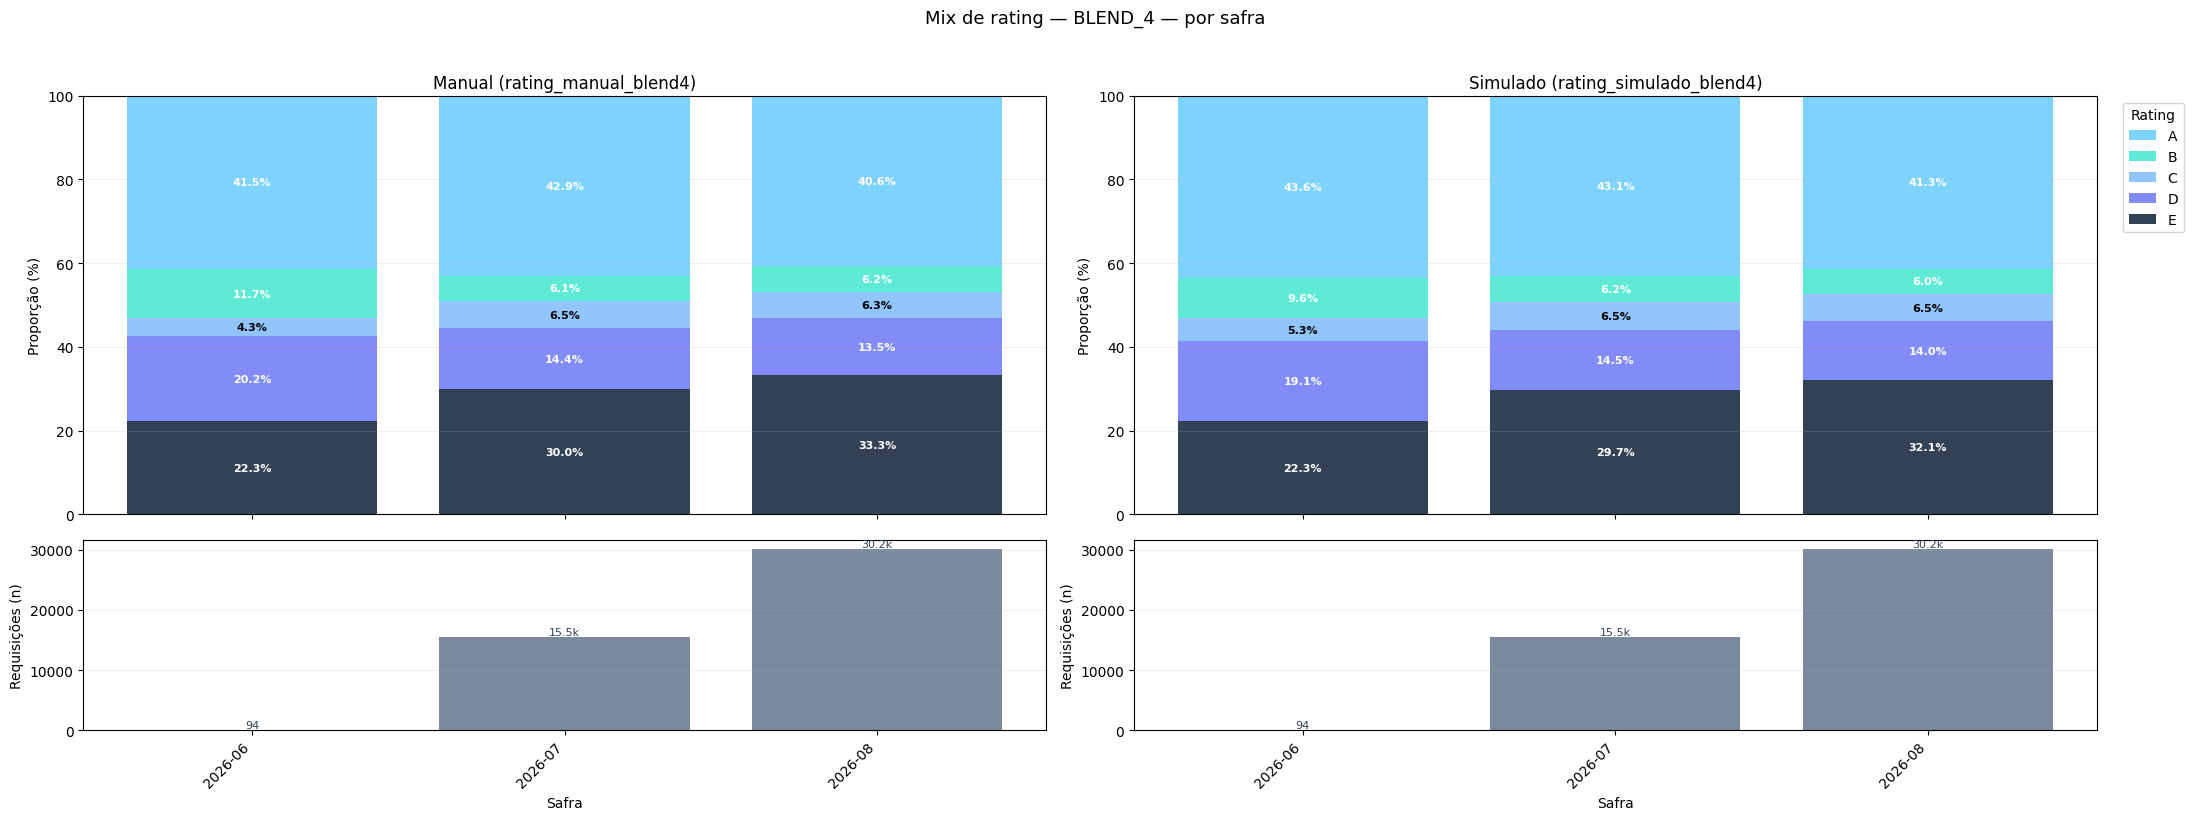

rating_manual_blend4,A,B,C,D,E,n
safra,,,,,,
2026-06,41.5,11.7,4.3,20.2,22.3,94
2026-07,42.9,6.1,6.5,14.4,30.0,15470
2026-08,40.6,6.2,6.3,13.5,33.3,30195


rating_simulado_blend4,A,B,C,D,E,n
safra,,,,,,
2026-06,43.6,9.6,5.3,19.1,22.3,94
2026-07,43.1,6.2,6.5,14.5,29.7,15470
2026-08,41.3,6.0,6.5,14.0,32.1,30195


In [864]:
safra_order = sorted(df_blend4["safra"].dropna().astype(str).unique())
(pct_manual_safra, vol_manual_safra), (pct_sim_safra, vol_sim_safra) = plot_rating_comparison_by_period(
    df_blend4,
    period_col="safra",
    period_order=safra_order,
    xlabel="Safra",
    title="Mix de rating — BLEND_4 — por safra",
)

display(pct_manual_safra.round(1).assign(n=vol_manual_safra).rename_axis("safra"))
display(pct_sim_safra.round(1).assign(n=vol_sim_safra).rename_axis("safra"))

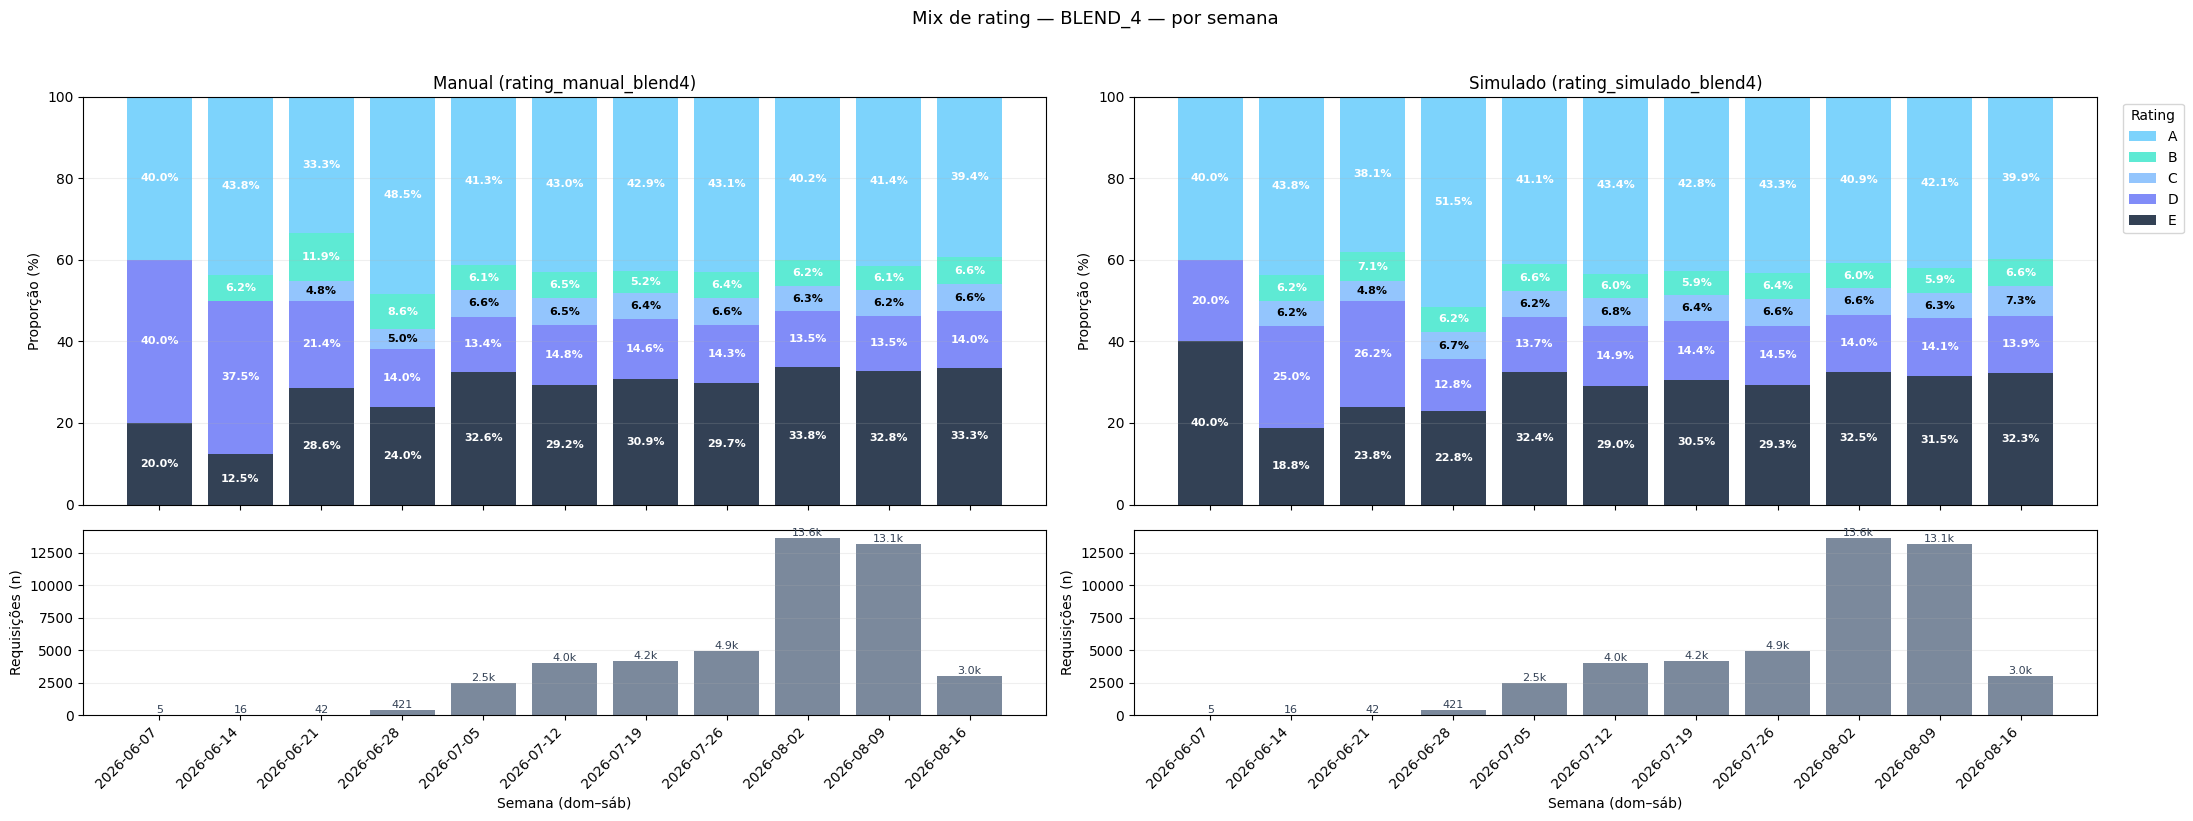

rating_manual_blend4,A,B,C,D,E,n
semana,,,,,,
2026-06-07,40.0,0.0,0.0,40.0,20.0,5
2026-06-14,43.8,6.2,0.0,37.5,12.5,16
2026-06-21,33.3,11.9,4.8,21.4,28.6,42
2026-06-28,48.5,8.6,5.0,14.0,24.0,421
2026-07-05,41.3,6.1,6.6,13.4,32.6,2476
2026-07-12,43.0,6.5,6.5,14.8,29.2,3997
2026-07-19,42.9,5.2,6.4,14.6,30.9,4192
2026-07-26,43.1,6.4,6.6,14.3,29.7,4901
2026-08-02,40.2,6.2,6.3,13.5,33.8,13596


rating_simulado_blend4,A,B,C,D,E,n
semana,,,,,,
2026-06-07,40.0,0.0,0.0,20.0,40.0,5
2026-06-14,43.8,6.2,6.2,25.0,18.8,16
2026-06-21,38.1,7.1,4.8,26.2,23.8,42
2026-06-28,51.5,6.2,6.7,12.8,22.8,421
2026-07-05,41.1,6.6,6.2,13.7,32.4,2476
2026-07-12,43.4,6.0,6.8,14.9,29.0,3997
2026-07-19,42.8,5.9,6.4,14.4,30.5,4192
2026-07-26,43.3,6.4,6.6,14.5,29.3,4901
2026-08-02,40.9,6.0,6.6,14.0,32.5,13596


In [865]:
week_order = (
    df_blend4[["year_week", "week_start"]]
    .drop_duplicates()
    .sort_values("week_start")["year_week"]
    .tolist()
)
(pct_manual_week, vol_manual_week), (pct_sim_week, vol_sim_week) = plot_rating_comparison_by_period(
    df_blend4,
    period_col="year_week",
    period_order=week_order,
    xlabel="Semana (dom–sáb)",
    title="Mix de rating — BLEND_4 — por semana",
)

display(pct_manual_week.round(1).assign(n=vol_manual_week).rename_axis("semana"))
display(pct_sim_week.round(1).assign(n=vol_sim_week).rename_axis("semana"))

## Substituição no Funil

In [866]:
RATING_GROUP_ORDER = {
    "A+": "A",
    "A": "A",
    "B+": "A",
    "B": "A",
    "C": "B",
    "D+": "C",
    "D": "D",
    "E": "E",
    "E-BVS": "E",
}

RATING_DS_POL_ORDER = {
    "A+":"1.A+",
    "A":"2.A",
    "B+":"3.B+",
    "B":"4.B",
    "C":"5.C",
    "D+":"6.D+",
    "D":"7.D",
    "E":"8.E",
    "E-BVS":"9.E-BVS",
}

In [867]:
df_raw = pd.read_csv(ANALYTICS_DIR / "df_funil_blend4.csv", low_memory=False)
df_raw["requested_at"] = pd.to_datetime(df_raw["requested_at"])

mask = df_raw["bureau_nm_ajust"] == "BLEND4"

df_raw["rating_score_group"] = df_raw["rating_score_ds"]
df_raw.loc[mask, "rating_score_group"] = (
    df_raw.loc[mask, "rating_score_ds"].replace(RATING_GROUP_ORDER)
)

df_raw["rating_score_ds"] = df_raw["rating_score_ds"]

df_raw.loc[mask, "rating_score_ds"] = (
    df_raw.loc[mask, "rating_score_ds"].replace(RATING_DS_POL_ORDER)
)

df_raw["modeloBlend_group"] = np.where(
    df_raw["is_fallback"] == 1,
    "Fallback",
    df_raw["modeloBlend"],
)

df_raw["bureau_nm_ajust"] = df_raw["bureau_nm_ajust"].replace(
    "BLEND3_4", "BLEND3"
)

df_raw["modeloBlend_group"] = df_raw["modeloBlend_group"].replace(
    "BLEND3_4", "BLEND3_3"
)

In [868]:
df_funil_blend4 = df_raw[df_raw["modeloBlend_group"] == "BLEND_4"]#Sem Fallback

In [869]:
df_funil_blend4.groupby("bureau_nm_ajust", dropna=False).size()

bureau_nm_ajust
BLEND4    51615
dtype: int64

In [870]:
df_funil_blend4.columns

Index(['contract_id', 'dt_lead', 'requested_at', 'iniciada_at', 'enviada_at',
       'activated_at', 'cancelled_at', 'dt_saida', 'tipo_contrato',
       'product_nm', 'modeloBlend', 'bureau_nm', 'modelo_blend',
       'bureau_nm_ajust', 'is_fallback', 'total_rental_value_informed_nr',
       'rental_value_nr', 'qtd_proponentes', 'score_imobiliaria',
       'person_restriction_total_value', 'bvs_cust_score_nr',
       'blend_regressao_predict_nr', 'rating_score_ds', 'person_deemed_income',
       'pre_analysis_result', 'lead_elegivel', 'proposta_iniciada',
       'proposta_enviada', 'proposta_aprovada', 'proposta_ativada',
       'is_activeted', 'first_comunicacao_date', 'first_competencia_date',
       'rating_cl_pol_blend4', 'rating_pol_blend4', 'rating_score_group',
       'modeloBlend_group'],
      dtype='object')

In [871]:
df_blend4[["rating_manual_blend4", "rating_simulado_blend4"]]

,rating_manual_blend4,rating_simulado_blend4
118,E,E
122,E,E
140,A,A
146,A,A
150,A,A
...,...,...
264731,B,B
264732,C,C
264733,E,E
264734,E,E


In [872]:
df_funil_blend4["contract_id"].count(), df_blend4["contract_id"].count()

(np.int64(51615), np.int64(45759))

In [873]:
JOIN_KEYS = ["contract_id"]#, "requested_at"]
RATING_COLS = ["rating_manual_blend4", "rating_simulado_blend4"]

df_funil_join = df_funil_blend4.copy()
df_funil_join["contract_id"] = pd.to_numeric(df_funil_join["contract_id"], errors="coerce").astype("Int64")
# df_funil_join["requested_at"] = pd.to_datetime(df_funil_join["requested_at"]).dt.normalize()

df_blend4_ratings = df_blend4[JOIN_KEYS + RATING_COLS].copy()
df_blend4_ratings["contract_id"] = pd.to_numeric(df_blend4_ratings["contract_id"], errors="coerce").astype("Int64")
# df_blend4_ratings["requested_at"] = pd.to_datetime(df_blend4_ratings["requested_at"]).dt.normalize()

n_right_raw = len(df_blend4_ratings)
n_right_dupes = int(df_blend4_ratings.duplicated(subset=JOIN_KEYS).sum())
df_blend4_ratings = df_blend4_ratings.drop_duplicates(subset=JOIN_KEYS, keep="first")

df_funil_sim = df_funil_join.merge(
    df_blend4_ratings,
    on=JOIN_KEYS,
    how="left",
    indicator=True,
)

n_left = len(df_funil_sim)
n_right = len(df_blend4_ratings)
n_left_matched = int((df_funil_sim["_merge"] == "both").sum())
n_right_matched = len(
    df_funil_sim.loc[df_funil_sim["_merge"] == "both", JOIN_KEYS].drop_duplicates()
)

pct_left_match = 100 * n_left_matched / n_left if n_left else np.nan
pct_right_match = 100 * n_right_matched / n_right if n_right else np.nan

print(f"Left  (funil):  {n_left_matched:,} / {n_left:,} matched ({pct_left_match:.1f}%)")
print(f"Right (blend4): {n_right_matched:,} / {n_right:,} matched ({pct_right_match:.1f}%)")
if n_right_dupes:
    print(f"Right duplicate keys dropped: {n_right_dupes:,} (from {n_right_raw:,} to {n_right:,})")

match_summary = pd.DataFrame(
    {
        "side": ["left (funil)", "right (blend4)"],
        "n_total": [n_left, n_right],
        "n_matched": [n_left_matched, n_right_matched],
        "n_unmatched": [n_left - n_left_matched, n_right - n_right_matched],
        "pct_match": [round(pct_left_match, 2), round(pct_right_match, 2)],
    }
)
display(match_summary)
df_funil_sim.head()


Left  (funil):  44,008 / 51,615 matched (85.3%)
Right (blend4): 44,008 / 45,759 matched (96.2%)


,side,n_total,n_matched,n_unmatched,pct_match
0,left (funil),51615,44008,7607,85.26
1,right (blend4),45759,44008,1751,96.17


,contract_id,dt_lead,requested_at,iniciada_at,enviada_at,activated_at,cancelled_at,dt_saida,tipo_contrato,product_nm,...,is_activeted,first_comunicacao_date,first_competencia_date,rating_cl_pol_blend4,rating_pol_blend4,rating_score_group,modeloBlend_group,rating_manual_blend4,rating_simulado_blend4,_merge
0,4341552,2026-07-07,2026-07-07,NaN,NaN,NaN,2026-07-07,NaN,PF,NaN,...,False,NaN,NaN,E-2.E,8.E,E,BLEND_4,E,E,both
1,4344868,2026-07-07,2026-07-07,NaN,NaN,NaN,2026-08-07,NaN,PF,NaN,...,False,NaN,NaN,1.A+,1.A+,A,BLEND_4,A,A,both
2,4345241,2026-07-07,2026-07-07,NaN,NaN,NaN,2026-08-07,NaN,PF,NaN,...,False,NaN,NaN,10.D,7.D,D,BLEND_4,D,D,both
3,4345763,2026-07-07,2026-07-07,2026-07-07,NaN,NaN,NaN,NaN,PF,Smart Plus,...,False,NaN,NaN,9.D+,6.D+,C,BLEND_4,C,B,both
4,4340874,2026-07-07,2026-07-07,2026-07-07,2026-07-07,2026-07-08,NaN,NaN,PF,Smart Plus,...,True,NaN,NaN,1.A+,1.A+,A,BLEND_4,A,A,both


In [874]:
df_funil_sim[["contract_id"]].count(), df_funil_sim[["contract_id"]].nunique()

(contract_id    51615
 dtype: int64,
 contract_id    51615
 dtype: int64)

In [875]:
df_funil_sim.groupby("_merge", dropna=False).size()

_merge
left_only      7607
right_only        0
both          44008
dtype: int64

In [876]:
df_funil_blend4[df_funil_blend4["contract_id"] == 4358668]

,contract_id,dt_lead,requested_at,iniciada_at,enviada_at,activated_at,cancelled_at,dt_saida,tipo_contrato,product_nm,...,proposta_enviada,proposta_aprovada,proposta_ativada,is_activeted,first_comunicacao_date,first_competencia_date,rating_cl_pol_blend4,rating_pol_blend4,rating_score_group,modeloBlend_group
40854,4358668,2026-07-10,2026-07-10,NaN,NaN,NaN,2026-08-10,NaN,PF,NaN,...,False,False,False,False,NaN,NaN,3.A,2.A,A,BLEND_4


In [877]:
df_blend4[df_blend4["contract_id"] == 4358668]

,CPF_CNPJ,contract_id,requested_at,data_ultima_consulta,qtd_proponentes,score_imobiliaria,model,id_consulta,id_funcionalidade,documento,...,safra,id_cidade_ibge,agency_id,city_pc4_mais_100_contratos__pc_categorias,agency_pc4_mais_100_contratos__pc_categorias,rating_simulado_blend4,week_start,year_week,year,week_of_year


In [878]:
df_funil_sim[df_funil_sim["_merge"] == "left_only"].groupby("rating_score_group", dropna=False).size()

rating_score_group
A       156
B       275
D       217
E      6859
N/I     100
dtype: int64

In [879]:
df_funil_sim[df_funil_sim["_merge"] == "left_only"]

,contract_id,dt_lead,requested_at,iniciada_at,enviada_at,activated_at,cancelled_at,dt_saida,tipo_contrato,product_nm,...,is_activeted,first_comunicacao_date,first_competencia_date,rating_cl_pol_blend4,rating_pol_blend4,rating_score_group,modeloBlend_group,rating_manual_blend4,rating_simulado_blend4,_merge
5,4345498,2026-07-07,2026-07-07,2026-07-08,2026-07-08,2026-07-08,NaN,NaN,PF,Smart Plus,...,True,NaN,NaN,NaN,N/I,D,BLEND_4,NaN,NaN,left_only
9,4337865,2026-07-06,2026-07-06,NaN,NaN,NaN,2026-07-06,NaN,PF,NaN,...,False,NaN,NaN,NaN,N/I,E,BLEND_4,NaN,NaN,left_only
15,4329854,2026-07-03,2026-07-03,NaN,NaN,NaN,2026-07-03,NaN,PF,NaN,...,False,NaN,NaN,NaN,N/I,E,BLEND_4,NaN,NaN,left_only
19,4347954,2026-07-08,2026-07-08,NaN,NaN,NaN,2026-07-08,NaN,PF,NaN,...,False,NaN,NaN,NaN,N/I,E,BLEND_4,NaN,NaN,left_only
20,4346905,2026-07-08,2026-07-08,NaN,NaN,NaN,2026-07-08,NaN,PF,NaN,...,False,NaN,NaN,NaN,N/I,E,BLEND_4,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51569,4468508,2026-08-05,2026-08-05,NaN,NaN,NaN,NaN,NaN,PF,NaN,...,False,NaN,NaN,NaN,N/I,E,BLEND_4,NaN,NaN,left_only
51573,4470326,2026-08-05,2026-08-05,NaN,NaN,NaN,2026-08-05,NaN,PF,NaN,...,False,NaN,NaN,NaN,N/I,E,BLEND_4,NaN,NaN,left_only
51578,4467327,2026-08-05,2026-08-05,NaN,NaN,NaN,2026-08-05,NaN,PF,NaN,...,False,NaN,NaN,NaN,N/I,E,BLEND_4,NaN,NaN,left_only
51589,4507851,2026-08-13,2026-08-13,NaN,NaN,NaN,2026-08-13,NaN,PF,NaN,...,False,NaN,NaN,NaN,N/I,E,BLEND_4,NaN,NaN,left_only


In [880]:
df_funil_sim["rating_manual_final"] = df_funil_sim["rating_manual_blend4"].fillna(
    df_funil_sim["rating_score_group"]
)
df_funil_sim["rating_simulado_final"] = df_funil_sim["rating_simulado_blend4"].fillna(
    df_funil_sim["rating_score_group"]
)

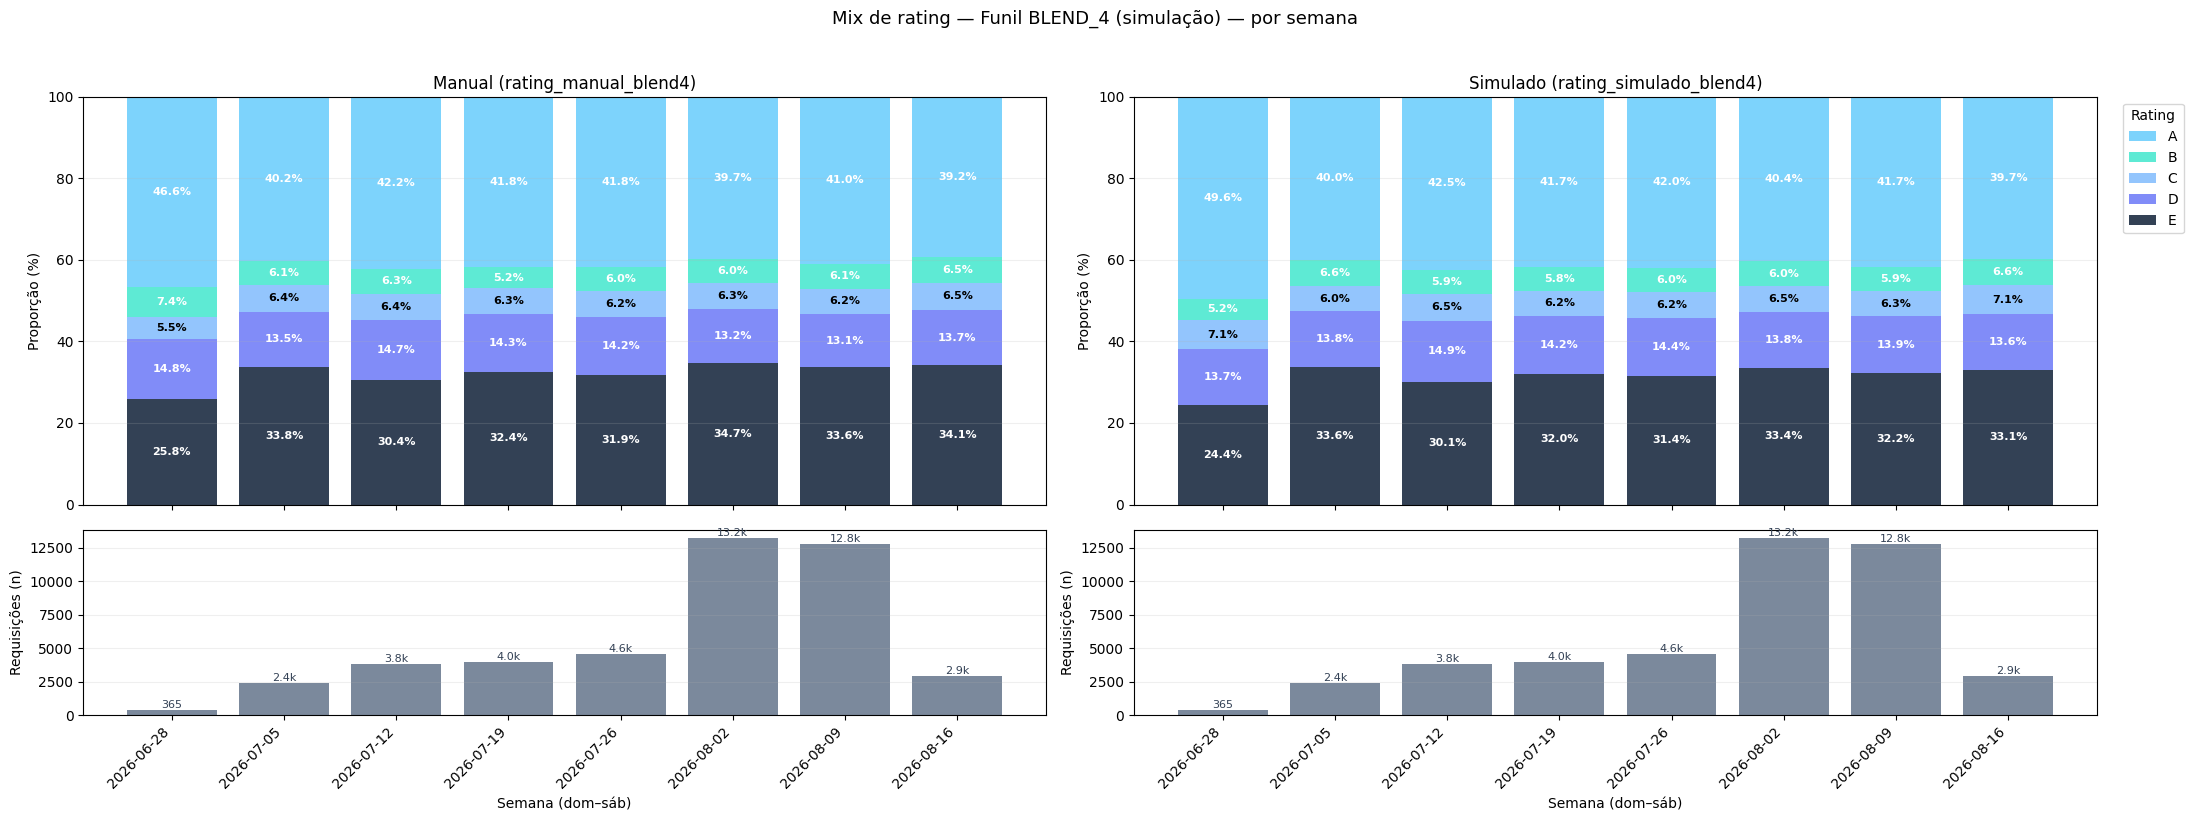

rating_manual_blend4,A,B,C,D,E,n
semana,,,,,,
2026-06-28,46.6,7.4,5.5,14.8,25.8,365
2026-07-05,40.2,6.1,6.4,13.5,33.8,2381
2026-07-12,42.2,6.3,6.4,14.7,30.4,3836
2026-07-19,41.8,5.2,6.3,14.3,32.4,3987
2026-07-26,41.8,6.0,6.2,14.2,31.9,4564
2026-08-02,39.7,6.0,6.3,13.2,34.7,13197
2026-08-09,41.0,6.1,6.2,13.1,33.6,12778
2026-08-16,39.2,6.5,6.5,13.7,34.1,2900


rating_simulado_blend4,A,B,C,D,E,n
semana,,,,,,
2026-06-28,49.6,5.2,7.1,13.7,24.4,365
2026-07-05,40.0,6.6,6.0,13.8,33.6,2381
2026-07-12,42.5,5.9,6.5,14.9,30.1,3836
2026-07-19,41.7,5.8,6.2,14.2,32.0,3987
2026-07-26,42.0,6.0,6.2,14.4,31.4,4564
2026-08-02,40.4,6.0,6.5,13.8,33.4,13197
2026-08-09,41.7,5.9,6.3,13.9,32.2,12778
2026-08-16,39.7,6.6,7.1,13.6,33.1,2900


In [881]:
df_funil_sim = prepare_week_columns(df_funil_sim, date_col="requested_at")
df_funil_sim_matched = df_funil_sim.loc[df_funil_sim["_merge"] == "both"].copy()

week_order_funil = (
    df_funil_sim_matched[["year_week", "week_start"]]
    .drop_duplicates()
    .sort_values("week_start")["year_week"]
    .tolist()
)
(pct_manual_week_funil, vol_manual_week_funil), (pct_sim_week_funil, vol_sim_week_funil) = plot_rating_comparison_by_period(
    df_funil_sim_matched,
    period_col="year_week",
    period_order=week_order_funil,
    xlabel="Semana (dom–sáb)",
    title="Mix de rating — Funil BLEND_4 (simulação) — por semana",
)

display(pct_manual_week_funil.round(1).assign(n=vol_manual_week_funil).rename_axis("semana"))
display(pct_sim_week_funil.round(1).assign(n=vol_sim_week_funil).rename_axis("semana"))


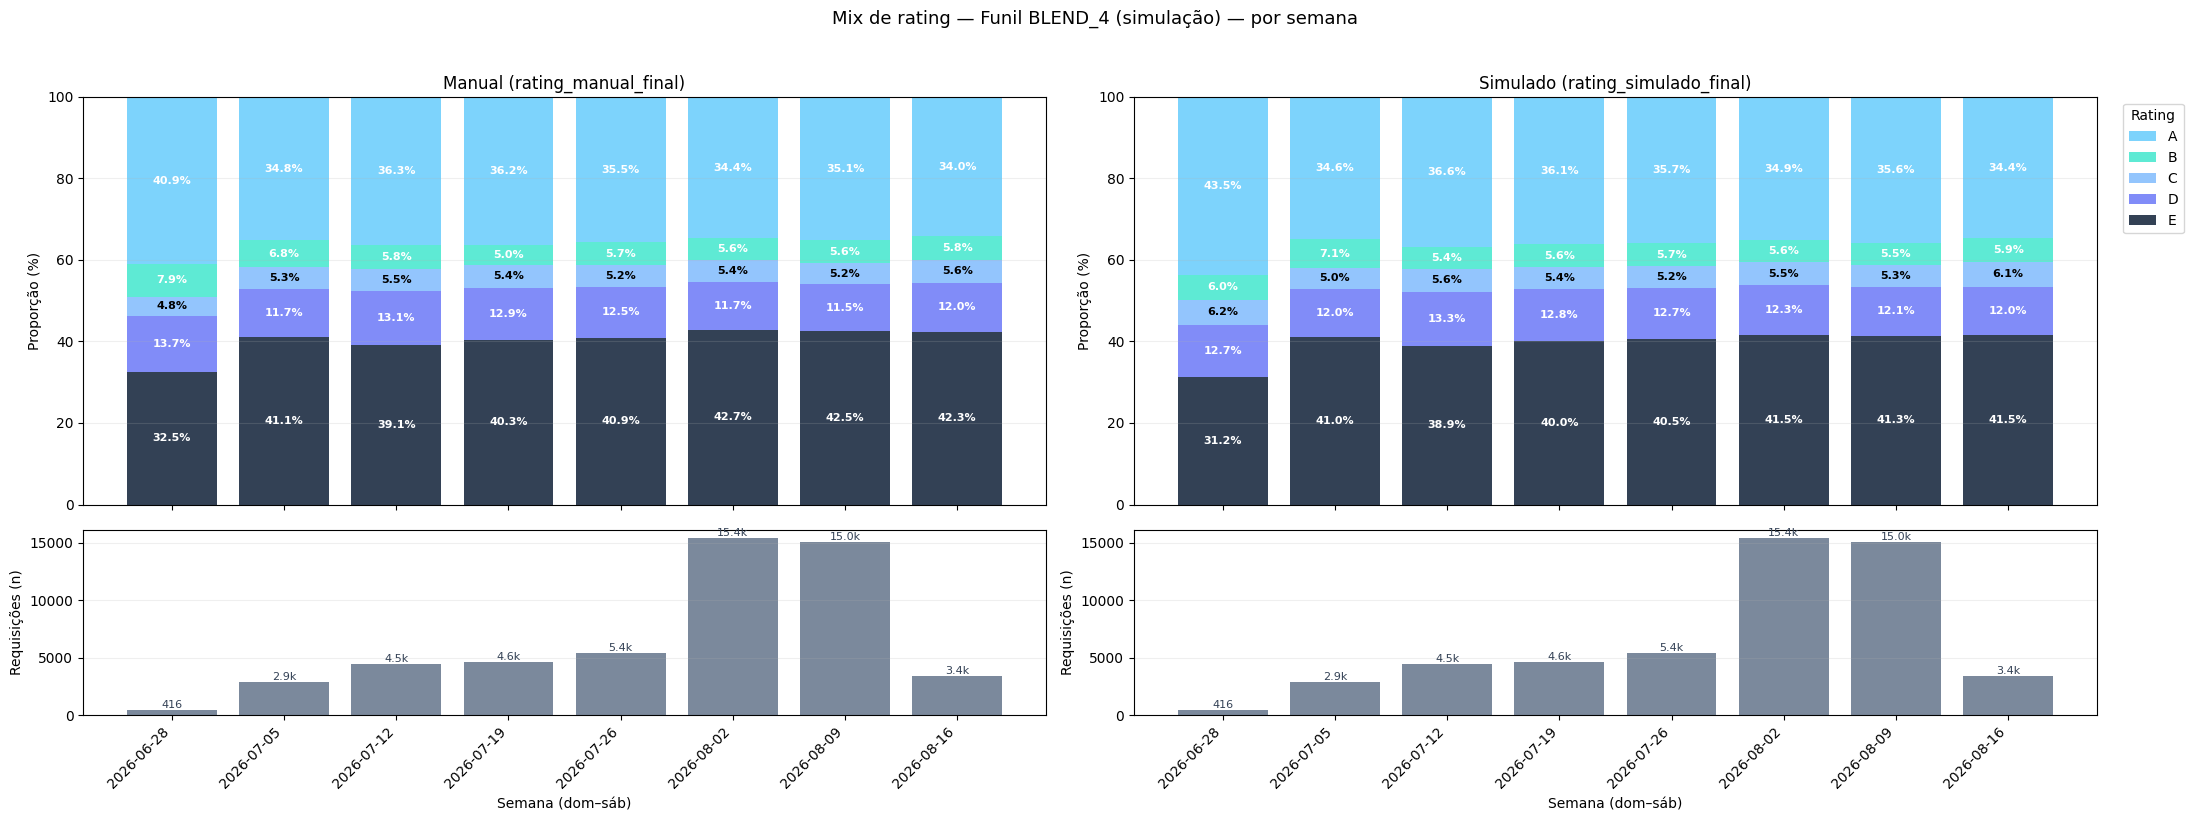

rating_manual_final,A,B,C,D,E,n
semana,,,,,,
2026-06-28,40.9,7.9,4.8,13.7,32.5,416
2026-07-05,34.8,6.8,5.3,11.7,41.1,2888
2026-07-12,36.3,5.8,5.5,13.1,39.1,4476
2026-07-19,36.2,5.0,5.4,12.9,40.3,4628
2026-07-26,35.5,5.7,5.2,12.5,40.9,5411
2026-08-02,34.4,5.6,5.4,11.7,42.7,15384
2026-08-09,35.1,5.6,5.2,11.5,42.5,15040
2026-08-16,34.0,5.8,5.6,12.0,42.3,3372


rating_simulado_final,A,B,C,D,E,n
semana,,,,,,
2026-06-28,43.5,6.0,6.2,12.7,31.2,416
2026-07-05,34.6,7.1,5.0,12.0,41.0,2888
2026-07-12,36.6,5.4,5.6,13.3,38.9,4476
2026-07-19,36.1,5.6,5.4,12.8,40.0,4628
2026-07-26,35.7,5.7,5.2,12.7,40.5,5411
2026-08-02,34.9,5.6,5.5,12.3,41.5,15384
2026-08-09,35.6,5.5,5.3,12.1,41.3,15040
2026-08-16,34.4,5.9,6.1,12.0,41.5,3372


In [882]:
df_funil_sim = prepare_week_columns(df_funil_sim, date_col="requested_at")
# df_funil_sim_matched = df_funil_sim.loc[df_funil_sim["_merge"] == "both"].copy()

week_order_funil = (
    df_funil_sim[["year_week", "week_start"]]
    .drop_duplicates()
    .sort_values("week_start")["year_week"]
    .tolist()
)
(pct_manual_week_funil, vol_manual_week_funil), (pct_sim_week_funil, vol_sim_week_funil) = plot_rating_comparison_by_period(
    df_funil_sim,
    period_col="year_week",
    period_order=week_order_funil,
    xlabel="Semana (dom–sáb)",
    title="Mix de rating — Funil BLEND_4 (simulação) — por semana",
    left_col="rating_manual_final",
    right_col="rating_simulado_final",
    left_title="Manual (rating_manual_final)",
    right_title="Simulado (rating_simulado_final)",
)

display(pct_manual_week_funil.round(1).assign(n=vol_manual_week_funil).rename_axis("semana"))
display(pct_sim_week_funil.round(1).assign(n=vol_sim_week_funil).rename_axis("semana"))


In [884]:
mig = pd.crosstab(
    df_funil_sim["rating_manual_final"],
    df_funil_sim["rating_simulado_final"],
    dropna=False,
)

mig_pct = pd.crosstab(
    df_funil_sim["rating_manual_final"],
    df_funil_sim["rating_simulado_final"],
    normalize="index",
    dropna=False,
)

display(mig.assign(total=mig.sum(axis=1)))
display(mig_pct.round(1).assign(total=mig_pct.sum(axis=1).round(1)))

rating_simulado_final,A,B,C,D,E,N/I,total
rating_manual_final,,,,,,,
A,17872,220,7,0,0,0,18099
B,434,2266,207,18,0,0,2925
C,3,426,2066,264,0,0,2759
D,0,3,530,5359,301,0,6193
E,0,0,0,744,20795,0,21539
N/I,0,0,0,0,0,100,100


rating_simulado_final,A,B,C,D,E,N/I,total
rating_manual_final,,,,,,,
A,1.0,0.0,0.0,0.0,0.0,0.0,1.0
B,0.1,0.8,0.1,0.0,0.0,0.0,1.0
C,0.0,0.2,0.7,0.1,0.0,0.0,1.0
D,0.0,0.0,0.1,0.9,0.0,0.0,1.0
E,0.0,0.0,0.0,0.0,1.0,0.0,1.0
N/I,0.0,0.0,0.0,0.0,0.0,1.0,1.0
